In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, classification_report
import seaborn as sns
import numpy as np


In [81]:
# Load Result
svm = pd.read_csv("svm_results5.csv")
lr = pd.read_csv("lr_results5.csv")

In [82]:
svm.rename(columns={"HeartDisease": "actual"}, inplace=True)
lr.rename(columns={"HeartDisease": "actual"}, inplace=True)

# Error Analysis

## 1. Add Error Type Column to each model

In [83]:
def tag_error(row):
    if row['actual'] == 1 and row['predicted'] == 1:
        return 'True Positive'
    elif row['actual'] == 0 and row['predicted'] == 0:
        return 'True Negative'
    elif row['actual'] == 0 and row['predicted'] == 1:
        return 'False Positive'
    elif row['actual'] == 1 and row['predicted'] == 0:
        return 'False Negative'

svm['ErrorType'] = svm.apply(tag_error, axis=1)
lr['ErrorType'] = lr.apply(tag_error, axis=1)


## 2. Count Each Error Type (Pie/Bar)

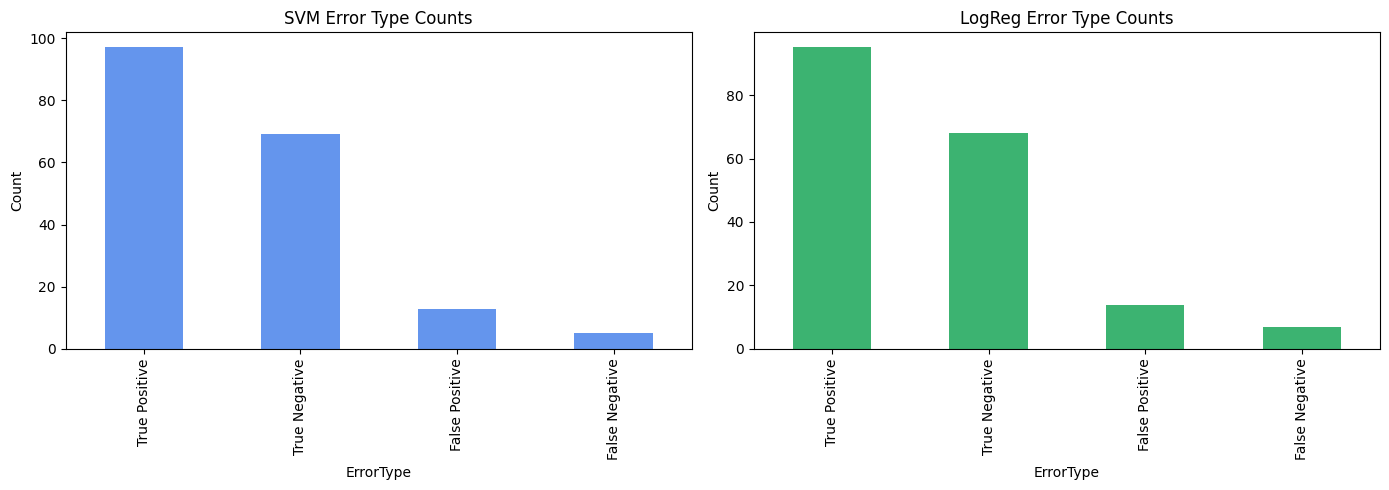

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SVM Error
svm['ErrorType'].value_counts().plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title("SVM Error Type Counts")
axes[0].set_ylabel("Count")

# LR Error
lr['ErrorType'].value_counts().plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title("LogReg Error Type Counts")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## Evaluate accuracy & AUC

In [85]:
# Accuracy
acc_svm = accuracy_score(svm['actual'], svm['predicted'])
acc_lr = accuracy_score(lr['actual'], lr['predicted'])

# AUC
auc_svm = roc_auc_score(svm['actual'], svm['probability'])
auc_lr = roc_auc_score(lr['actual'], lr['probability'])

print(f"SVM Accuracy: {acc_svm:.2f}, AUC: {auc_svm:.2f}")
print(f"LR Accuracy: {acc_lr:.2f}, AUC: {auc_lr:.2f}")


SVM Accuracy: 0.90, AUC: 0.94
LR Accuracy: 0.89, AUC: 0.93


# 2. Performance Visual

## Plot confusion Matrices Side-by-Side

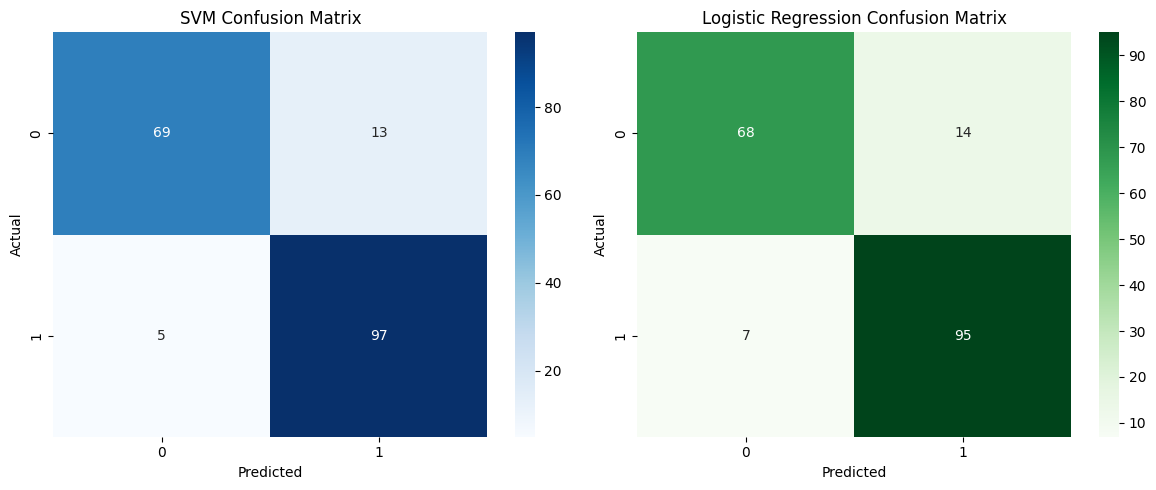

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# SVM
sns.heatmap(confusion_matrix(svm['actual'], svm['predicted']), annot=True, fmt='d',
            cmap='Blues', ax=axes[0])
axes[0].set_title("SVM Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# LR
sns.heatmap(confusion_matrix(lr['actual'], lr['predicted']), annot=True, fmt='d',
            cmap='Greens', ax=axes[1])
axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## Plot ROC Curve

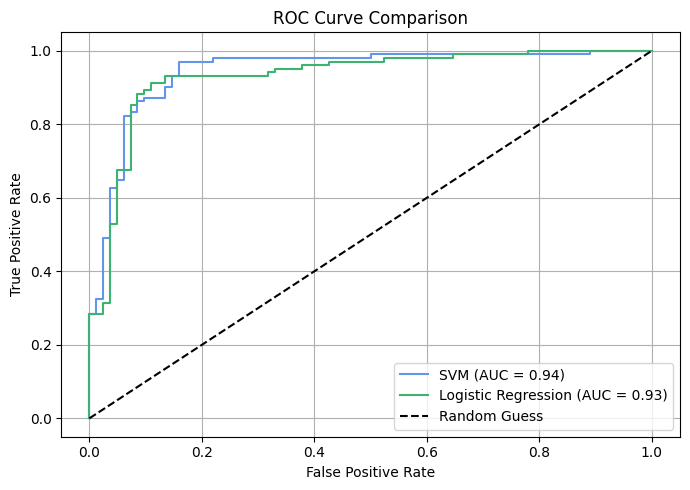

In [87]:
fpr_svm, tpr_svm, _ = roc_curve(svm['actual'], svm['probability'])
fpr_lr, tpr_lr, _ = roc_curve(lr['actual'], lr['probability'])

plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})", color='cornflowerblue')
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})", color='mediumseagreen')
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Bar Chart

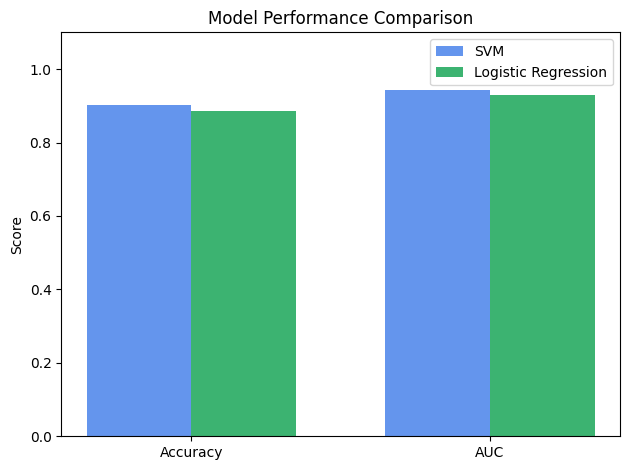

In [88]:
metrics = ['Accuracy', 'AUC']
svm_scores = [acc_svm, auc_svm]
lr_scores = [acc_lr, auc_lr]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, svm_scores, width, label='SVM', color='cornflowerblue')
ax.bar(x + width/2, lr_scores, width, label='Logistic Regression', color='mediumseagreen')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


## Probability Histogram (Model Confidence)

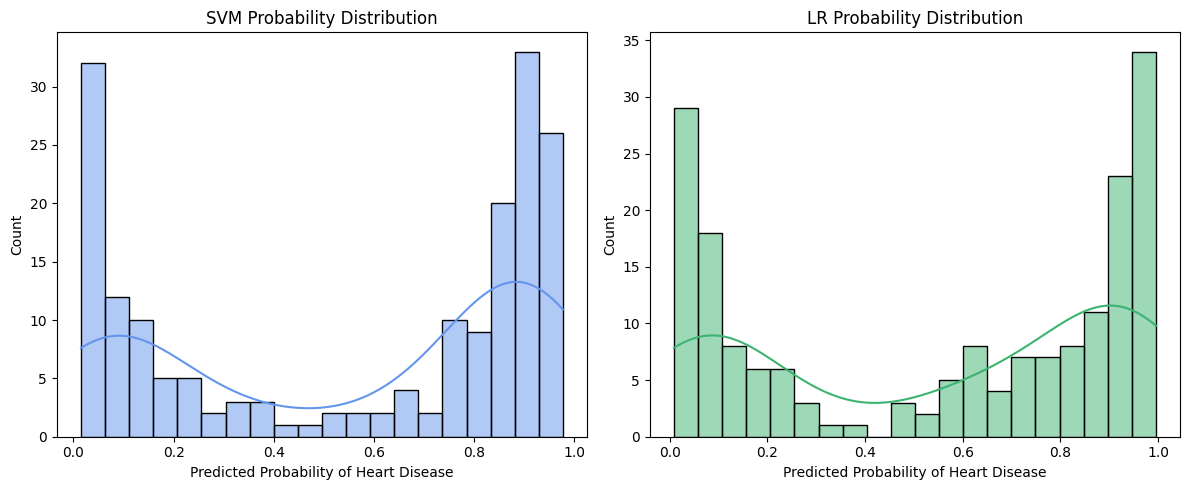

In [89]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(svm['probability'], bins=20, kde=True, color='cornflowerblue')
plt.title("SVM Probability Distribution")
plt.xlabel("Predicted Probability of Heart Disease")

plt.subplot(1, 2, 2)
sns.histplot(lr['probability'], bins=20, kde=True, color='mediumseagreen')
plt.title("LR Probability Distribution")
plt.xlabel("Predicted Probability of Heart Disease")

plt.tight_layout()
plt.show()


## Confidence vs Error Type

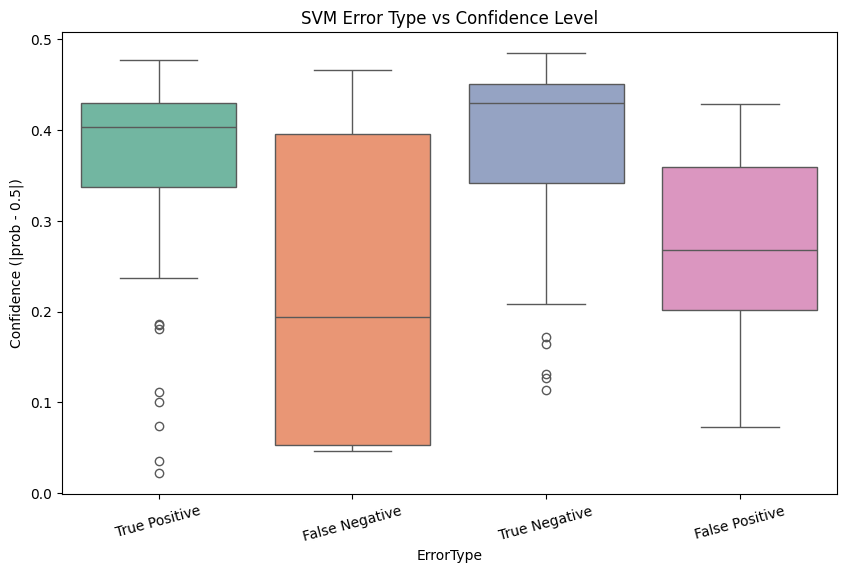

In [90]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='ErrorType', y='confidence', data=svm, hue='ErrorType', palette='Set2', legend=False)
plt.title("SVM Error Type vs Confidence Level")
plt.ylabel("Confidence (|prob - 0.5|)")
plt.xticks(rotation=15)
plt.show()

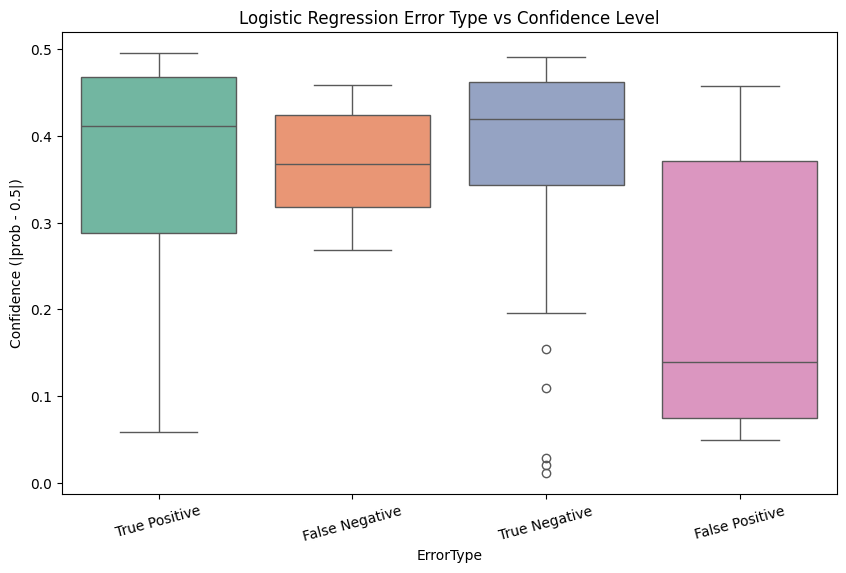

In [91]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='ErrorType', y='confidence', data=lr, hue='ErrorType', palette='Set2', legend=False)
plt.title("Logistic Regression Error Type vs Confidence Level")
plt.ylabel("Confidence (|prob - 0.5|)")
plt.xticks(rotation=15)
plt.show()

# 3. Advanced Error Breakdown

## View False Negatives & False Positives (High-risk in medical ML)


In [92]:
# False Negatives (actual = 1, predicted = 0)
fn_svm = svm[(svm['actual'] == 1) & (svm['predicted'] == 0)]
fn_lr = lr[(lr['actual'] == 1) & (lr['predicted'] == 0)]

print("False Negatives - SVM:", len(fn_svm))
print("False Negatives - LR:", len(fn_lr))

# False Positives (actual = 0, predicted = 1)
fp_svm = svm[(svm['actual'] == 0) & (svm['predicted'] == 1)]
fp_lr = lr[(lr['actual'] == 0) & (lr['predicted'] == 1)]

print("False Positives - SVM:", len(fp_svm))
print("False Positives - LR:", len(fp_lr))


False Negatives - SVM: 5
False Negatives - LR: 7
False Positives - SVM: 13
False Positives - LR: 14


## Error rate as percentage

In [93]:
def error_percentage(df):
    total = len(df)
    fn = len(df[(df['actual'] == 1) & (df['predicted'] == 0)])
    fp = len(df[(df['actual'] == 0) & (df['predicted'] == 1)])
    return {
        "False Negative %": fn / total * 100,
        "False Positive %": fp / total * 100
    }

print("Error Rate - SVM:", error_percentage(svm))
print("Error Rate - LR:", error_percentage(lr))


Error Rate - SVM: {'False Negative %': 2.717391304347826, 'False Positive %': 7.065217391304348}
Error Rate - LR: {'False Negative %': 3.804347826086957, 'False Positive %': 7.608695652173914}


## Error by Confidence Level

In [94]:
# Add absolute confidence
svm['confidence'] = abs(svm['probability'] - 0.5)
lr['confidence'] = abs(lr['probability'] - 0.5)

# Sort by least confident predictions
print("SVM Low Confidence Errors:")
print(svm[svm['ErrorType'] != 'True Positive'].sort_values(by='confidence').head())

print("\nLR Low Confidence Errors:")
print(lr[lr['ErrorType'] != 'True Positive'].sort_values(by='confidence').head())


SVM Low Confidence Errors:
     actual  predicted  probability       ErrorType  confidence
1         1          0     0.453568  False Negative    0.046432
41        1          0     0.446628  False Negative    0.053372
55        0          1     0.573045  False Positive    0.073045
122       0          0     0.385924   True Negative    0.114076
58        0          0     0.372783   True Negative    0.127217

LR Low Confidence Errors:
     actual  predicted  probability       ErrorType  confidence
47        0          0     0.488309   True Negative    0.011691
146       0          0     0.479235   True Negative    0.020765
90        0          0     0.471030   True Negative    0.028970
83        0          1     0.549101  False Positive    0.049101
49        0          1     0.550573  False Positive    0.050573


## F1 score


In [95]:
# F1 for Logistic Regression
f1_lr = f1_score(lr['actual'], lr['predicted'])
print(f"Logistic Regression F1 Score: {f1_lr:.2f}")

# F1 for SVM
f1_svm = f1_score(svm['actual'], svm['predicted'])
print(f"SVM F1 Score: {f1_svm:.2f}")


Logistic Regression F1 Score: 0.90
SVM F1 Score: 0.92


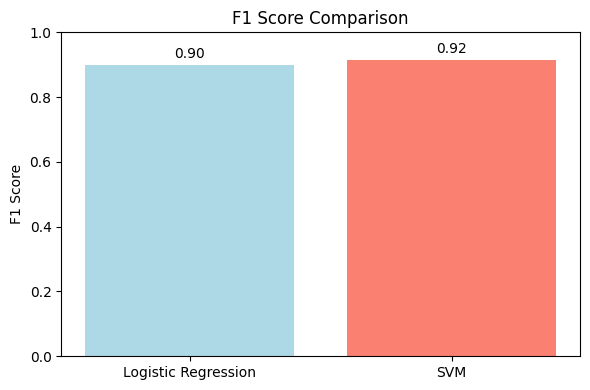

In [96]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'SVM']
f1_scores = [f1_lr, f1_svm]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, f1_scores, color=['lightblue', 'salmon'])
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', ha='center')

plt.tight_layout()
plt.show()


## Classification report

In [97]:
# Logistic Regression Report
print("Logistic Regression - Classification Report")
print(classification_report(lr['actual'], lr['predicted'], target_names=["No Disease", "Heart Disease"]))

# SVM Report
print("SVM - Classification Report")
print(classification_report(svm['actual'], svm['predicted'], target_names=["No Disease", "Heart Disease"]))


Logistic Regression - Classification Report
               precision    recall  f1-score   support

   No Disease       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184

SVM - Classification Report
               precision    recall  f1-score   support

   No Disease       0.93      0.84      0.88        82
Heart Disease       0.88      0.95      0.92       102

     accuracy                           0.90       184
    macro avg       0.91      0.90      0.90       184
 weighted avg       0.90      0.90      0.90       184



In [98]:
# Calculate metrics
metrics = {
    'Model': ['Logistic Regression', 'SVM'],
    'Precision': [
        precision_score(lr['actual'], lr['predicted']),
        precision_score(svm['actual'], svm['predicted'])
    ],
    'Recall': [
        recall_score(lr['actual'], lr['predicted']),
        recall_score(svm['actual'], svm['predicted'])
    ],
    'F1 Score': [
        f1_score(lr['actual'], lr['predicted']),
        f1_score(svm['actual'], svm['predicted'])
    ]
}

# Create DataFrame
summary_df = pd.DataFrame(metrics)
summary_df.set_index("Model", inplace=True)
print("Model Performance Summary:")
print(summary_df.round(2))


Model Performance Summary:
                     Precision  Recall  F1 Score
Model                                           
Logistic Regression       0.87    0.93      0.90
SVM                       0.88    0.95      0.92


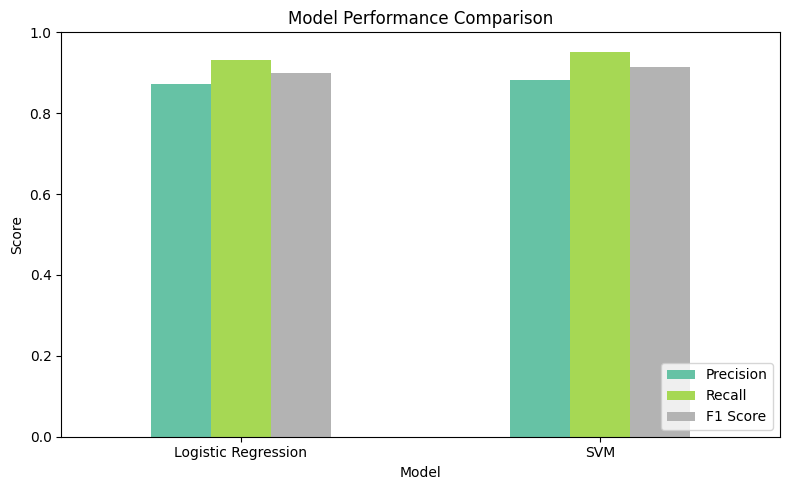

In [99]:
# Bar chart
summary_df.plot(kind='bar', figsize=(8, 5), colormap='Set2')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
